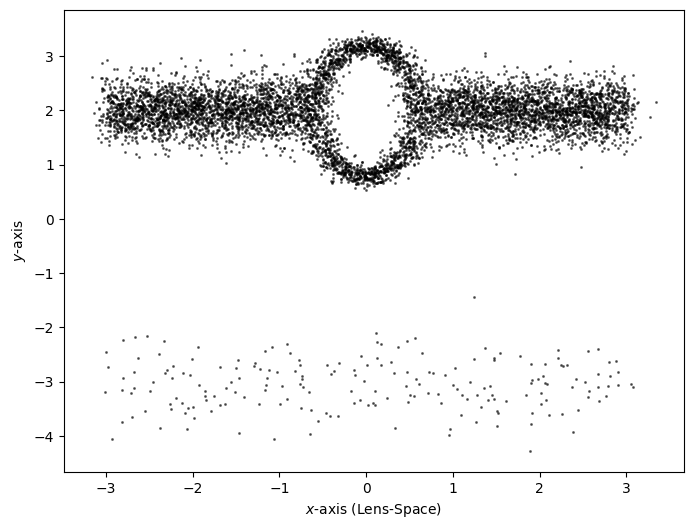

In [ ]:
import numpy as np
from numpy.random import randn
import matplotlib.pyplot as plt
from pathlib import Path

# Make folders
folder_path = Path("data")
folder_path.mkdir(parents=True, exist_ok=True)
folder_path = Path("figures")
folder_path.mkdir(parents=True, exist_ok=True)

# The data will be generated in three pieces
# - The loop 
# - The rest of the component containing the loop
# - The second component

# Generate the loop:
angles = np.random.randn(2000,)
circle = np.array([
    0.6*np.cos(2*np.pi*angles), 1.2*np.sin(2*np.pi*angles)+2
]).T
circle += 0.1*np.random.randn(2000,2) 
left=np.amin(circle[:,0])+0.13
right=np.amax(circle[:,0])-0.13

# Generate the rest of the loop's component
handle_leftx = np.linspace(-3,left,2500)+ 0.1*np.random.randn(2500,)
handle_rightx = np.linspace(right,3,2500)+ 0.1*np.random.randn(2500,)
handle_x = np.hstack((handle_leftx,handle_rightx))
handle = np.array([
    handle_x, 0.3*np.random.randn(5000,)+2
]).T
dense = np.vstack((handle, circle)) # combine the dense component into one array

# Generate the sparse component
sparse_x = np.linspace(-3,3,200)
sparse_x += 0.1*np.random.randn(200,)
sparse = np.array([
   sparse_x, 0.5*np.random.randn(200,)-3
]).T

# Combine arrays and save as .npy
points = np.vstack((dense, sparse))
np.save("./data/genus1_demo.npy",points)

# Generate Figure
fig, ax = plt.subplots(1, figsize=(8,6))
#ax.set_title("Synthetic data with varied lens-space density")
ax.scatter(
    points[:,0], points[:,1],
    marker='.',
    s=5,
    c='k',
    alpha=0.5
)
ax.set_xlabel(r'$x$-axis (Lens-Space)')
ax.set_ylabel(r'$y$-axis')
plt.savefig("fig6.png")
plt.show(fig)

In [41]:
import numpy as np
from numpy.random import randn
import matplotlib.pyplot as plt

def generate_consistent(n_pts, loc, width, ndim=1):
    # Sample a component centered at `loc`, with width `width`
    x,y=loc
    widthx,widthy=width
    x_axis = widthx * np.random.randn(n_pts,) + x
    y_axis = widthy * np.random.randn(n_pts,) + y
    t_axis = 10*np.random.rand(n_pts,)
    
    cluster_consistent = np.array([
        x_axis,
        y_axis,
        t_axis,
    ])
    return cluster_consistent.T


# Generate three components with differing number of points
cpt1 = generate_consistent(200, (3,0), (0.3,0.2))
cpt2 = generate_consistent(600, (0,0), (0.3,0.2))
cpt3 = generate_consistent(1800, (-3,0), (0.3,0.2))

# Concatenate the arrays to save as a .npy file
cluster_merge = np.concatenate((cpt1,cpt2,cpt3),axis=0)
cluster_merge = np.squeeze(cluster_merge)
intended_clusters = [0]*200 + [1]*600 + [2]*1800
np.save( "data/density_demo_data.npy", cluster_merge)



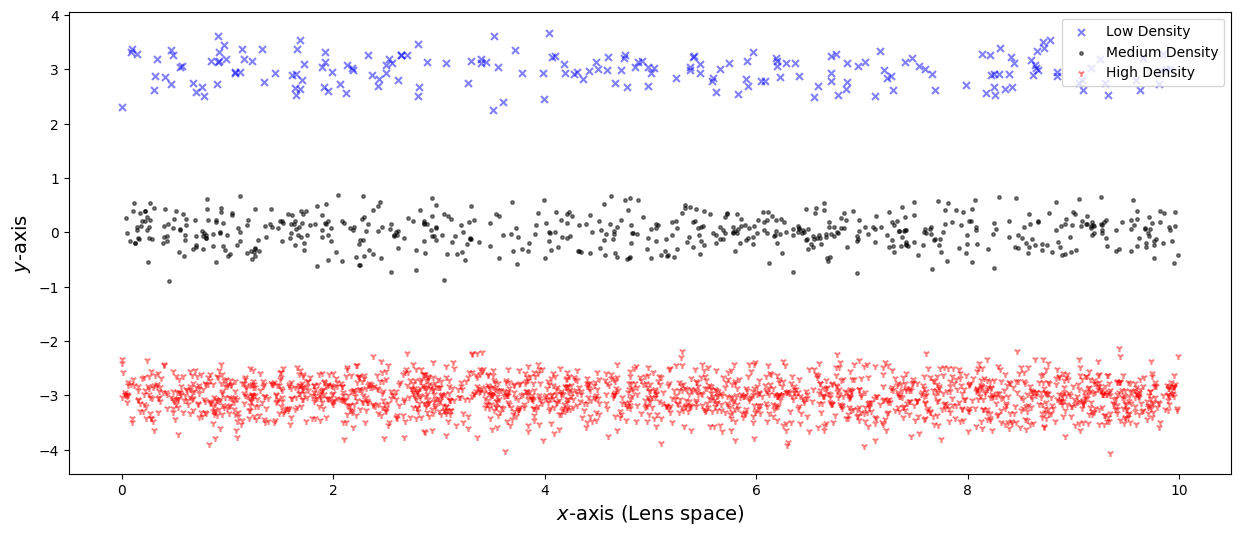

In [43]:
##
fig,ax = plt.subplots(1,1, figsize=(15, 6))
ax.scatter(
    cpt1[:,2],
    cpt1[:,0],
    s=25,
    alpha=0.5,
    label='Low Density',
    marker='x',
    c='blue'
)
ax.scatter(
    cpt2[:,2],
    cpt2[:,0],
    s=25,
    alpha=0.5,
    label='Medium Density',
    marker='.',
    c='k'
)
ax.scatter(
    cpt3[:,2],
    cpt3[:,0],
    s=25,
    alpha=0.5,
    label='High Density',
    marker='1',
    c='red'
)
plt.legend()
plt.xlabel(r'$x$-axis (Lens space)',fontsize=14)
plt.ylabel(r'$y$-axis',fontsize=14)
plt.savefig('pullback-test.png', dpi=300)
plt.show()